In [1]:
import copy
import random

import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from gymnasium.spaces import Box
from tqdm import tqdm

## TD3 - Twin Delayed Deep Deterministic Policy Gradient

TD3 is an off-policy actor-critic algorithm for continuous action spaces. It extends DDPG with three stabilizers:

1. **Clipped double-Q learning** - train two critics and use the smaller target value.
2. **Delayed policy updates** - update the actor less often than the critics.
3. **Target policy smoothing** - add clipped noise to the target action before evaluating target critics.

Core loop in plain words:

```text
initialize actor pi_theta, critics Q_phi1 and Q_phi2, and target copies
for each environment step:
    act randomly for start_steps, then use pi_theta(s) plus exploration noise
    store (s, a, r, s_next, done) in replay buffer
    every update_every steps after update_after:
        sample minibatches from replay buffer
        update both Q networks toward the clipped double-Q target
        every policy_delay critic updates, update the actor and target networks
```

**TD target used here:**

```text
a_next = clip(pi_targ(s_next) + clip(noise, -noise_clip, noise_clip), action_low, action_high)
y = r + gamma * (1 - done) * min(Q_targ1(s_next, a_next), Q_targ2(s_next, a_next))
```

**Actor loss minimized here:**

```text
L_pi = -mean(Q_phi1(s, pi_theta(s)))
```

### 1. ReplayBuffer

TD3 is off-policy like DQN and SAC, so it reuses past transitions from a replay buffer. Actions are continuous vectors, so they are stored as float arrays.

The `done` flag records true termination only. Time-limit truncation resets the environment, but it is not treated as terminal for the infinite-horizon Bellman target.

In [2]:
class ReplayBuffer(object):
    def __init__(self, obs_dim, act_dim, size, batch_size, device):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.obs2_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)
        self.max_size = size
        self.batch_size = batch_size
        self.device = device
        self.ptr = 0
        self.size = 0

    def insert(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.obs2_buf[self.ptr] = next_obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self):
        if self.size < self.batch_size:
            raise ValueError("Not enough samples in replay buffer")

        idxs = np.random.randint(0, self.size, size=self.batch_size)
        batch = dict(
            obs=self.obs_buf[idxs],
            obs2=self.obs2_buf[idxs],
            act=self.act_buf[idxs],
            rew=self.rew_buf[idxs],
            done=self.done_buf[idxs],
        )
        return {
            key: torch.as_tensor(value, dtype=torch.float32, device=self.device)
            for key, value in batch.items()
        }

    def __len__(self):
        return self.size

### 2. Actor and Critic Networks

The actor is deterministic: `pi(s)` maps each state directly to one bounded continuous action. Exploration is added outside the actor during environment interaction.

Each critic maps `(state, action)` to one scalar Q-value. TD3 trains two critics and uses the smaller target estimate to reduce overestimation bias.

In [3]:
def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for j in range(len(sizes) - 1):
        act = activation if j < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[j], sizes[j + 1]), act()]
    return nn.Sequential(*layers)


class DeterministicActor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, action_low, action_high):
        super().__init__()
        self.net = mlp([obs_dim, *hidden_sizes, act_dim])

        action_low = torch.as_tensor(action_low, dtype=torch.float32)
        action_high = torch.as_tensor(action_high, dtype=torch.float32)
        self.register_buffer("action_low", action_low)
        self.register_buffer("action_high", action_high)
        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)

    def forward(self, obs):
        return self.action_bias + self.action_scale * torch.tanh(self.net(obs))


class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes):
        super().__init__()
        self.q = mlp([obs_dim + act_dim, *hidden_sizes, 1])

    def forward(self, obs, act):
        q = self.q(torch.cat([obs, act], dim=-1))
        return torch.squeeze(q, -1)


class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, action_low, action_high):
        super().__init__()
        self.pi = DeterministicActor(obs_dim, act_dim, hidden_sizes, action_low, action_high)
        self.q1 = QNetwork(obs_dim, act_dim, hidden_sizes)
        self.q2 = QNetwork(obs_dim, act_dim, hidden_sizes)

    def act(self, obs):
        if not torch.is_tensor(obs):
            obs = torch.as_tensor(obs, dtype=torch.float32, device=next(self.parameters()).device)
        if obs.ndim == 1:
            obs = obs.unsqueeze(0)

        with torch.no_grad():
            action = self.pi(obs)
        return action.cpu().numpy()[0]

### 3. RunTD3 - Training Loop

Methods map directly to the TD3 algorithm:

| Method | Role |
|---|---|
| `choose_action` | uniform random warmup, then deterministic actor plus exploration noise |
| `_compute_loss_q` | Bellman backup with clipped double-Q and target policy smoothing |
| `_compute_loss_pi` | deterministic policy gradient objective through `Q1` |
| `_update` | critic update every time, actor and target update every `policy_delay` |
| `learn` | step-based environment interaction loop |

`update_every` follows the same style as SAC: every `k` environment steps, the code performs `k` gradient updates.

In [4]:
class RunTD3(object):
    def __init__(self,
                 env,
                 pi_lr=1e-3,
                 q_lr=1e-3,
                 batch_size=100,
                 gamma=0.99,
                 polyak=0.995,
                 hidden_sizes=(256, 256),
                 replay_size=1_000_000,
                 start_steps=10_000,
                 update_after=1_000,
                 update_every=50,
                 policy_delay=2,
                 act_noise=0.1,
                 target_noise=0.2,
                 noise_clip=0.5,
                 max_ep_len=1_000,
                 grad_clip=None,
                 eval_env_fn=None,
                 device=None):

        if not isinstance(env.action_space, Box):
            raise ValueError("TD3 in this notebook expects a continuous Box action space")
        if not np.all(np.isfinite(env.action_space.low)) or not np.all(np.isfinite(env.action_space.high)):
            raise ValueError("TD3 needs finite action bounds")
        if policy_delay < 1:
            raise ValueError("policy_delay must be at least 1")

        self.env = env
        self.eval_env_fn = eval_env_fn
        self.env_id = env.spec.id if getattr(env, "spec", None) is not None else None
        self.pi_lr = pi_lr
        self.q_lr = q_lr
        self.batch_size = batch_size
        self.gamma = gamma
        self.polyak = polyak
        self.hidden_sizes = tuple(hidden_sizes)
        self.replay_size = replay_size
        self.start_steps = start_steps
        self.update_after = update_after
        self.update_every = update_every
        self.policy_delay = policy_delay
        self.act_noise = act_noise
        self.target_noise = target_noise
        self.noise_clip = noise_clip
        self.max_ep_len = max_ep_len
        self.grad_clip = grad_clip
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.dim_S = env.observation_space.shape[0]
        self.dim_A = env.action_space.shape[0]
        self.action_low = torch.as_tensor(env.action_space.low, dtype=torch.float32, device=self.device)
        self.action_high = torch.as_tensor(env.action_space.high, dtype=torch.float32, device=self.device)
        self.action_low_np = env.action_space.low
        self.action_high_np = env.action_space.high
        self.action_dtype = env.action_space.dtype

        self.replay_buffer = ReplayBuffer(
            obs_dim=self.dim_S,
            act_dim=self.dim_A,
            size=self.replay_size,
            batch_size=self.batch_size,
            device=self.device,
        )

        self.ac = ActorCritic(
            obs_dim=self.dim_S,
            act_dim=self.dim_A,
            hidden_sizes=self.hidden_sizes,
            action_low=env.action_space.low,
            action_high=env.action_space.high,
        ).to(self.device)
        self.ac_targ = copy.deepcopy(self.ac).to(self.device)

        for param in self.ac_targ.parameters():
            param.requires_grad = False

        self.q_params = list(self.ac.q1.parameters()) + list(self.ac.q2.parameters())
        self.pi_optimizer = optim.Adam(self.ac.pi.parameters(), lr=self.pi_lr)
        self.q_optimizer = optim.Adam(self.q_params, lr=self.q_lr)

        self.total_env_steps = 0
        self.total_updates = 0

    def _reset_env(self, seed=None, env=None):
        env = self.env if env is None else env
        reset_result = env.reset(seed=seed) if seed is not None else env.reset()
        return reset_result[0] if isinstance(reset_result, tuple) else reset_result

    def _step_env(self, action, env=None):
        env = self.env if env is None else env
        step_result = env.step(action)
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
        else:
            next_state, reward, done, _ = step_result
            terminated, truncated = done, False
        return next_state, reward, terminated, truncated

    def choose_action(self, state, deterministic=False):
        if self.total_env_steps < self.start_steps and not deterministic:
            return self.env.action_space.sample()

        action = self.ac.act(state)
        if not deterministic:
            action = action + self.act_noise * np.random.randn(self.dim_A)
        return np.clip(action, self.action_low_np, self.action_high_np).astype(self.action_dtype)

    def _compute_loss_q(self, batch):
        obs, act = batch["obs"], batch["act"]
        rew, obs2, done = batch["rew"], batch["obs2"], batch["done"]

        q1 = self.ac.q1(obs, act)
        q2 = self.ac.q2(obs, act)

        with torch.no_grad():
            noise = torch.randn_like(act) * self.target_noise
            noise = torch.clamp(noise, -self.noise_clip, self.noise_clip)
            next_action = self.ac_targ.pi(obs2) + noise
            next_action = torch.max(torch.min(next_action, self.action_high), self.action_low)

            q1_targ = self.ac_targ.q1(obs2, next_action)
            q2_targ = self.ac_targ.q2(obs2, next_action)
            q_targ = torch.min(q1_targ, q2_targ)
            backup = rew + self.gamma * (1 - done) * q_targ

        loss_q1 = F.mse_loss(q1, backup)
        loss_q2 = F.mse_loss(q2, backup)
        loss_q = loss_q1 + loss_q2

        return loss_q, {
            "loss_q1": loss_q1.item(),
            "loss_q2": loss_q2.item(),
            "q1": q1.mean().item(),
            "q2": q2.mean().item(),
        }

    def _compute_loss_pi(self, batch):
        obs = batch["obs"]
        action = self.ac.pi(obs)
        loss_pi = -self.ac.q1(obs, action).mean()
        return loss_pi, {"loss_pi": loss_pi.item()}

    def _polyak_update(self):
        with torch.no_grad():
            for param, param_targ in zip(self.ac.parameters(), self.ac_targ.parameters()):
                param_targ.data.mul_(self.polyak)
                param_targ.data.add_((1 - self.polyak) * param.data)

    def _update(self):
        batch = self.replay_buffer.sample()

        self.q_optimizer.zero_grad()
        loss_q, info = self._compute_loss_q(batch)
        loss_q.backward()
        if self.grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(self.q_params, self.grad_clip)
        self.q_optimizer.step()

        self.total_updates += 1

        if self.total_updates % self.policy_delay == 0:
            for param in self.q_params:
                param.requires_grad = False

            self.pi_optimizer.zero_grad()
            loss_pi, pi_info = self._compute_loss_pi(batch)
            loss_pi.backward()
            if self.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(self.ac.pi.parameters(), self.grad_clip)
            self.pi_optimizer.step()

            for param in self.q_params:
                param.requires_grad = True

            self._polyak_update()
            info.update(pi_info)

        return info

    def _make_eval_env(self):
        if self.eval_env_fn is not None:
            return self.eval_env_fn(), True
        if self.env_id is not None:
            return gym.make(self.env_id), True
        return self.env, False

    def test_agent(self, num_episodes=5):
        eval_env, should_close = self._make_eval_env()
        returns = []
        try:
            for _ in range(num_episodes):
                state = self._reset_env(env=eval_env)
                ep_ret = 0.0
                for _ in range(self.max_ep_len):
                    action = self.ac.act(state)
                    state, reward, terminated, truncated = self._step_env(action, env=eval_env)
                    ep_ret += reward
                    if terminated or truncated:
                        break
                returns.append(ep_ret)
        finally:
            if should_close:
                eval_env.close()
        return returns

    def learn(self, total_steps, eval_every=5_000, num_test_episodes=5):
        state = self._reset_env()
        ep_ret, ep_len = 0.0, 0
        episode_rewards = []
        losses = []
        eval_returns = []

        for t in tqdm(range(total_steps)):
            action = self.choose_action(state)
            next_state, reward, terminated, truncated = self._step_env(action)
            ep_ret += reward
            ep_len += 1
            self.total_env_steps += 1

            timeout = ep_len == self.max_ep_len or truncated
            done_for_buffer = float(terminated)
            self.replay_buffer.insert(state, action, reward, next_state, done_for_buffer)
            state = next_state

            if terminated or timeout:
                episode_rewards.append(ep_ret)
                state = self._reset_env()
                ep_ret, ep_len = 0.0, 0

            if t >= self.update_after and t % self.update_every == 0:
                for _ in range(self.update_every):
                    losses.append(self._update())

            if eval_every is not None and (t + 1) % eval_every == 0:
                eval_scores = self.test_agent(num_episodes=num_test_episodes)
                eval_returns.append({
                    "step": t + 1,
                    "mean_return": float(np.mean(eval_scores)),
                    "std_return": float(np.std(eval_scores)),
                })

        return episode_rewards, losses, eval_returns

### 4. Train on Pendulum-v1 (single seed)

TD3 is designed for continuous control, so `Pendulum-v1` is a lightweight sanity-check environment. Early interaction uses random actions, then the deterministic actor takes over with Gaussian exploration noise.

Rewards are negative in Pendulum. Improvement usually appears as the curve rising toward less-negative returns.

100%|██████████| 25000/25000 [00:48<00:00, 517.95it/s]


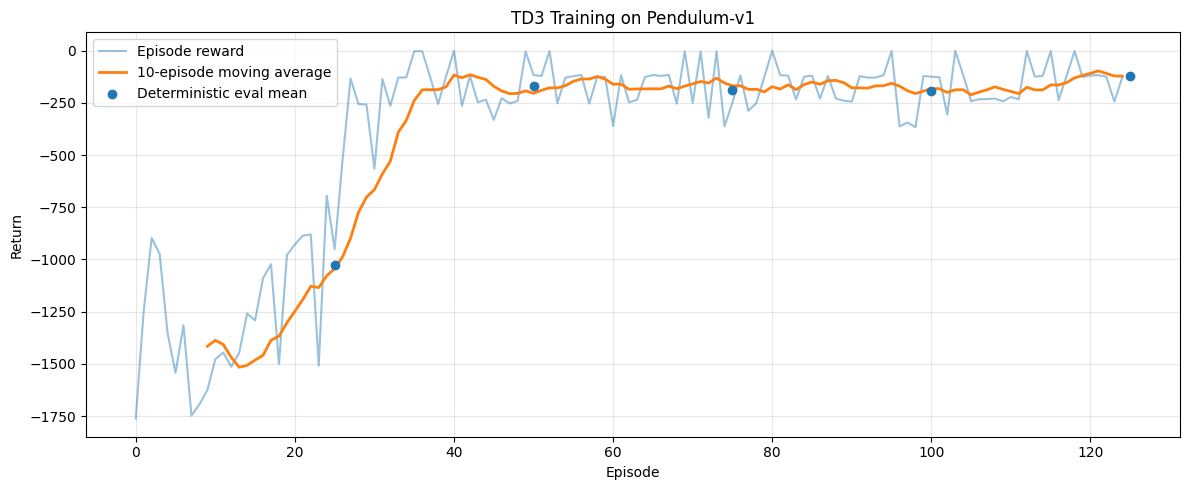

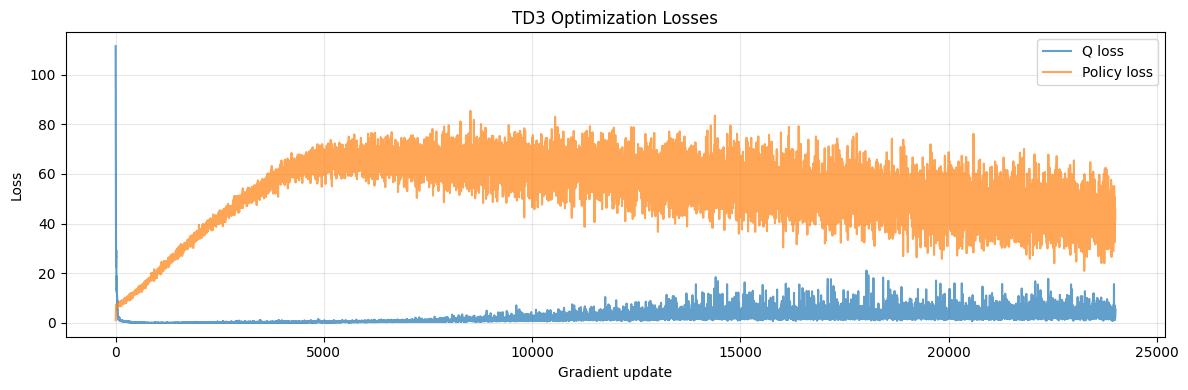

In [5]:
import matplotlib.pyplot as plt

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

env = gym.make("Pendulum-v1")
env.reset(seed=seed)
env.action_space.seed(seed)

agent = RunTD3(
    env=env,
    pi_lr=1e-3,
    q_lr=1e-3,
    batch_size=100,
    gamma=0.99,
    polyak=0.995,
    hidden_sizes=(256, 256),
    replay_size=100_000,
    start_steps=1_000,
    update_after=1_000,
    update_every=50,
    policy_delay=2,
    act_noise=0.1,
    target_noise=0.2,
    noise_clip=0.5,
    max_ep_len=200,
)

episode_rewards, losses, eval_returns = agent.learn(
    total_steps=25_000,
    eval_every=5_000,
    num_test_episodes=5,
)
env.close()

window = min(10, len(episode_rewards))
moving_average = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, label="Episode reward", alpha=0.45)
plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    label=f"{window}-episode moving average",
    linewidth=2,
)
if eval_returns:
    plt.scatter(
        [item["step"] / 200 for item in eval_returns],
        [item["mean_return"] for item in eval_returns],
        label="Deterministic eval mean",
        zorder=3,
    )
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("TD3 Training on Pendulum-v1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if losses:
    q_losses = [item["loss_q1"] + item["loss_q2"] for item in losses]
    pi_losses = [item["loss_pi"] for item in losses if "loss_pi" in item]

    plt.figure(figsize=(12, 4))
    plt.plot(q_losses, label="Q loss", alpha=0.7)
    if pi_losses:
        plt.plot(
            np.linspace(0, len(q_losses) - 1, len(pi_losses)),
            pi_losses,
            label="Policy loss",
            alpha=0.7,
        )
    plt.xlabel("Gradient update")
    plt.ylabel("Loss")
    plt.title("TD3 Optimization Losses")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 5. Multi-seed evaluation

Three seeds with identical hyperparameters, following the DQN, PPO, and SAC notebooks. Each run is smoothed with a moving average, then the across-seed mean plus/minus one standard deviation is plotted.

This cell takes longer than the single-seed sanity check. Reduce `TOTAL_STEPS` while debugging, then raise it when collecting report results.

100%|██████████| 25000/25000 [00:46<00:00, 537.07it/s]


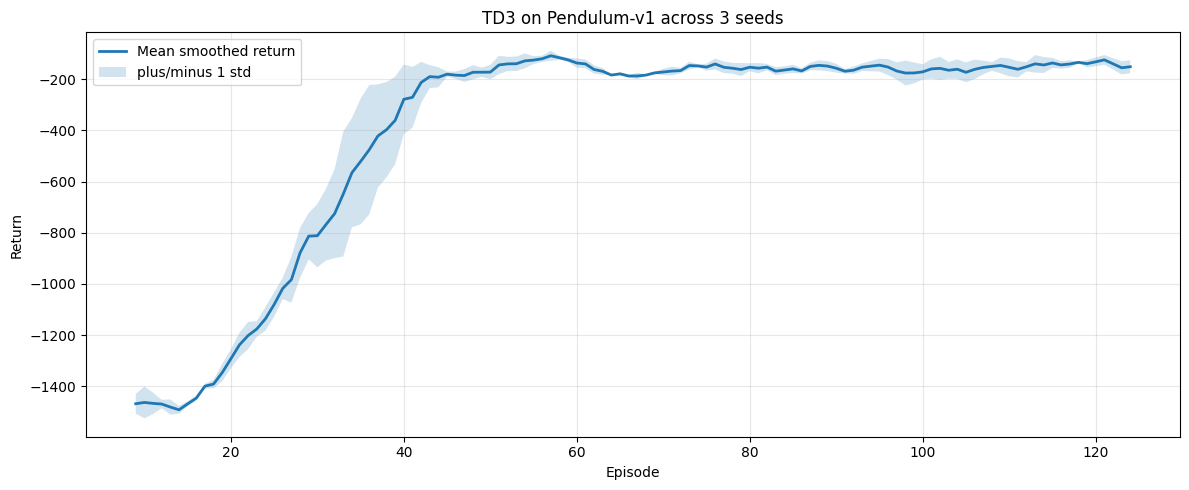

In [6]:
SEEDS = [0, 16, 25]
TOTAL_STEPS = 25_000
WINDOW = 10

reward_runs = []
eval_runs = []

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env = gym.make("Pendulum-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = RunTD3(
        env=env,
        pi_lr=1e-3,
        q_lr=1e-3,
        batch_size=100,
        gamma=0.99,
        polyak=0.995,
        hidden_sizes=(256, 256),
        replay_size=100_000,
        start_steps=1_000,
        update_after=1_000,
        update_every=50,
        policy_delay=2,
        act_noise=0.1,
        target_noise=0.2,
        noise_clip=0.5,
        max_ep_len=200,
    )

    episode_rewards, _, eval_returns = agent.learn(
        total_steps=TOTAL_STEPS,
        eval_every=5_000,
        num_test_episodes=5,
    )
    env.close()

    reward_runs.append(np.array(episode_rewards, dtype=np.float32))
    eval_runs.append(eval_returns)

min_len = min(len(run) for run in reward_runs)
smoothed = []
for run in reward_runs:
    run = run[:min_len]
    smoothed.append(np.convolve(run, np.ones(WINDOW) / WINDOW, mode="valid"))

smoothed = np.vstack(smoothed)
mean_rewards = smoothed.mean(axis=0)
std_rewards = smoothed.std(axis=0)
x = np.arange(WINDOW - 1, WINDOW - 1 + len(mean_rewards))

plt.figure(figsize=(12, 5))
plt.plot(x, mean_rewards, label="Mean smoothed return", linewidth=2)
plt.fill_between(
    x,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha=0.2,
    label="plus/minus 1 std",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("TD3 on Pendulum-v1 across 3 seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()